<span style="background-color: #f60">IMPORTANT NOTE:</span><br/>
***This workbook is a copy of the notebook provided on [ML for people course](https://www.dataloves.academy/courses/machine-learning) with few minor changes. Current version was run on 16 of May, 2026***

# Парсинг вакансій та аналіз навичок Data Scientist: Від збору даних до інсайтів з українського тексту

У цьому уроці-майстер-класі ми зробимо один з типів Data Science проєктів, які зустрічаються в індустрії і який буде класним доповненням в Ваше портфоліо. 

**Задача:** Виявити, які конкретні навички прямо зараз є актуальними на ринку в обраному напрямі. В нашому випадку, Data Science.

Для цього нам необхідно
- Зібрати актуальні вакансії;
- Проаналізувати текст вакансій;
- Виявити навички в вакансіях;
- Зробити висновки.

В ході виконання завдання ми
- навчимося автоматично збирати дані з вебсайту (ця процедера називається "парсинг") за допомогою бібліотеки `selenium`;
- побудуємо візуалізацію WordCloud для аналізу текстів;
- познайомимось з поняттям n-грамів в обробці природньої мови;
- використаємо ChatGPT за АРІ аби "почистити" тексти вакансії від зайвої інформації і проставити лейбли для вакансій.

Збирати актуальні вакансії будемо в сфері Data Science з ресурсу DOU.ua, працюватимемо з українською та англіською мовами, та в результаті визначимо, які навички є найбільш затребуваними для фахівців з даних (data scientist).

В цьому уроці ми будемо працювати з web-сторінками, тому нам треба познайомитись з поняттям HTML.

## Коротке інтро, що таке HTML

**HTML (HyperText Markup Language)** — це стандартна мова розмітки, яка використовується для створення та структурування контенту вебсторінок в інтернеті. Вона дозволяє розмічати текст і додавати до нього різні елементи, такі як заголовки, абзаци, зображення, посилання, форми тощо.

Основні поняття HTML:

1. **Теги:**  
   HTML використовує теги для позначення різних елементів сторінки. Теги обмежуються кутовими дужками (`< >`) і зазвичай мають початковий і завершальний вигляд, наприклад:
   ```html
   <p>Це абзац тексту.</p>
   ```
   Деякі теги можуть бути самозакритими, наприклад, для зображень:
   ```html
   <img src="image.jpg" alt="Опис зображення" />
   ```

2. **Атрибути:**  
   Теги можуть містити атрибути, які надають додаткову інформацію про елемент. Наприклад, атрибут `src` вказує на джерело зображення, а `alt` описує його.
   ```html
   <img src="logo.png" alt="Логотип компанії" />
   ```

3. **Елементи:**  
   Елемент HTML складається з відкриваючого тегу, контенту та закриваючого тегу. Елементи можуть містити текст або інші елементи (вкладені елементи).
   ```html
   <h1>Заголовок сторінки</h1>
   ```

4. **Документна структура:**  
   Типовий HTML-документ має структуру з таких основних елементів:
   - `<!DOCTYPE html>` — вказує на тип документа.
   - `<html>` — кореневий тег документа.
   - `<head>` — містить метадані сторінки (стилі, метаінформація, скрипти).
   - `<body>` — містить видимий контент сторінки (текст, зображення, форми тощо).

   Наприклад:
   ```html
   <!DOCTYPE html>
   <html lang="uk">
     <head>
       <meta charset="UTF-8">
       <title>Назва сторінки</title>
     </head>
     <body>
       <h1>Вітаємо на нашому сайті!</h1>
       <p>Це перший абзац на сторінці.</p>
     </body>
   </html>
   ```

**Основна функція HTML** — це визначення структури і зовнішнього вигляду вебсторінки, яка потім відображається браузером. А от для додавання стилів (CSS) або інтерактивності (JavaScript) використовуються інші мови.

In [6]:
!pip install selenium chromedriver_autoinstaller -q

In [7]:
from selenium import webdriver
from bs4 import BeautifulSoup
import pandas as pd
import time
import requests
from tqdm import tqdm

import chromedriver_autoinstaller as chromedriver
chromedriver.install()

from selenium.webdriver.common.by import By

CHROME >= 115, using mac-arm64 as architecture identifier


Зараз ми будемо парсити сторінку з вакансіями для Data Science, використовуючи бібліотеку Selenium. Першим кроком є відкриття вебсторінки, яка містить ці вакансії, за допомогою вебдрайвера Chrome. Для цього ми ініціалізуємо драйвер і вказуємо йому відкрити URL-адресу сторінки з вакансіями на DOU. 



In [8]:
driver = webdriver.Chrome()

driver.get('https://jobs.dou.ua/vacancies/?category=Data+Science')


На цьому етапі наш драйвер завантажує HTML-код сторінки, що дає нам можливість витягувати з нього необхідну інформацію. Далі ми будемо шукати конкретні елементи на сторінці, такі як заголовки вакансій, вимоги та інші деталі, і зберігати їх для подальшого аналізу.

Ми реалізуємо механізм для автоматичного завантаження більшої кількості вакансій на сторінці. Більшість сайтів, включаючи DOU, не показують всі вакансії одразу, тому користувачу потрібно натискати кнопку "Завантажити більше", щоб відобразити додаткові вакансії. Ми імітуємо дії користувача з `selenium`. І для цього робимо цикл:
1. У кожній ітерації циклу ми шукаємо елемент на сторінці, який відповідає кнопці для завантаження додаткових вакансій.
2. Після кожного кліка ми додаємо паузу в 3 секунди, щоб дати сторінці час на завантаження нових вакансій.
3. Якщо на сторінці більше немає кнопки "Завантажити більше" або виникає інша помилка (наприклад, елемент не знайдено), виконання програми перехоплює виключення, виводить повідомлення про завершення і виходить з циклу. 

In [9]:
while True:
    try:
        driver.find_element(By.CSS_SELECTOR, 'div.more-btn a').click()
        time.sleep(3)
    except Exception as ex:
        print(ex)
        print('End.')
        break

Message: element not interactable
  (Session info: chrome=148.0.7778.168); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#elementnotinteractableexception
Stacktrace:
0   chromedriver                        0x0000000102716584 cxxbridge1$str$ptr + 3225716
1   chromedriver                        0x000000010270e45c cxxbridge1$str$ptr + 3192652
2   chromedriver                        0x00000001021cf6f8 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 74644
3   chromedriver                        0x0000000102219004 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 375968
4   chromedriver                        0x000000010220f42c _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 336072
5   chromedriver                        0x000000010220eea8 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 334660
6   chromedriver                        0x000000010

На цьому етапі ми провантажили весь перелік вакансій обраної категорії і можемо завантажити їх у змінну.

Для зручності подальшої роботи ми використовуємо бібліотеку `BeautifulSoup`, яка має багато різного фукнціоналу для роботи з контентом в форматі html.

У даному випадку, `BeautifulSoup` виконує наступні дії:

1. **Парсинг HTML-контенту:**  
   Коли ми викликаємо `BeautifulSoup(content)`, бібліотека обробляє весь HTML-код, отриманий від вебдрайвера (`driver.page_source`). Вона перетворює його у зручний для роботи формат дерева, що дозволяє легко шукати та витягувати елементи сторінки.

2. **Створення об'єкта для подальшого аналізу:**  
   `soup` — це об'єкт, який містить всю структуру HTML. З його допомогою можна виконувати подальші операції: знаходити конкретні елементи сторінки, витягувати текстові дані, аналізувати посилання, таблиці, списки тощо.

Завдяки цьому ми можемо переходити до пошуку та витягування необхідної інформації зі сторінки, наприклад, посилань на вакансії, заголовків вакансій, вимог, імен компаній тощо.

In [10]:
content = driver.page_source
soup = BeautifulSoup(content)

In [12]:
# soup

In [ ]:
# driver.close()

У нас зараз вивантажена сторінка з усіма вакансіями і ми хочемо взяти посилання кожної з вакансій аби потім провантажити сторінки з описами вакансій. Для цього пишемо код, який шукає в html сторінки посилання на вакансії.

In [15]:
vac_list = soup.find_all('a',href=True, attrs={'class':'vt'})
project_href = [i['href'] for i in vac_list]

І такий результат ми отримали:

In [16]:
project_href

['https://jobs.dou.ua/companies/uklon/vacancies/352365/?from=list_hot',
 'https://jobs.dou.ua/companies/intellias/vacancies/353817/?from=list_hot',
 'https://jobs.dou.ua/companies/glovo/vacancies/321189/?from=list_hot',
 'https://jobs.dou.ua/companies/silpo/vacancies/344730/',
 'https://jobs.dou.ua/companies/artellence/vacancies/358157/',
 'https://jobs.dou.ua/companies/mono/vacancies/344875/',
 'https://jobs.dou.ua/companies/uklon/vacancies/352876/',
 'https://jobs.dou.ua/companies/omd-systems/vacancies/357726/',
 'https://jobs.dou.ua/companies/weltrade/vacancies/357704/',
 'https://jobs.dou.ua/companies/winstars-technology/vacancies/357670/',
 'https://jobs.dou.ua/companies/easy-decision-recruitment-agency/vacancies/357653/',
 'https://jobs.dou.ua/companies/united-tech/vacancies/357484/',
 'https://jobs.dou.ua/companies/echoua/vacancies/357443/',
 'https://jobs.dou.ua/companies/synergetica/vacancies/357435/',
 'https://jobs.dou.ua/companies/kyivstar/vacancies/357423/',
 'https://jobs

Тепер нам треба завантажити кожне з цих посилань та взяти з них текст вакансій.

In [17]:
headers={"User-Agent": "HTTPie/3.1.0"}

In [18]:
vacs = {
    'link': [],
    'name': [],
    'desc': []
}
for link in tqdm(project_href):
    page = requests.get(link, headers=headers)
    soup = BeautifulSoup(page.content, "html.parser")
    vacs['link'].append(link)
    vacs['name'].append(soup.title.text)
    vacs['desc'].append(soup.select('div.vacancy-section')[0].text)
    time.sleep(1)

100%|██████████| 49/49 [01:01<00:00,  1.26s/it]


In [19]:
len(vacs['link'])

49

Далі вже все просто: записуємо результат в датафрейм і використовуємо для подальших цілей.

In [20]:
df = pd.DataFrame(vacs)

In [21]:
df.head()

,link,name,desc
0,https://jobs.dou.ua/companies/uklon/vacancies/...,"Pricing Management Lead в Uklon, Київ | DOU","\nUklon — продуктова IT-компанія, що розробляє..."
1,https://jobs.dou.ua/companies/intellias/vacanc...,"Data Science Engineer в Intellias, віддалено |...","\nOur client is a company that enables people,..."
2,https://jobs.dou.ua/companies/glovo/vacancies/...,"Data Analyst в Glovo, Київ, віддалено | DOU","\nIf you’re here, it’s because you’re looking ..."
3,https://jobs.dou.ua/companies/silpo/vacancies/...,Middle Data Scientist (Operations Digital Twin...,\nFozzy Group is one of the largest trade indu...
4,https://jobs.dou.ua/companies/artellence/vacan...,Strong junior or middle Data scientist в Artel...,\nПРО КОМПАНІЮDriving the age of AI. Наша мета...


In [ ]:
df.to_csv('data/data_science_vacs.csv', index=False)

In [23]:
print(df.desc.loc[1])


Our client is a company that enables people, enterprises, and cities to harness the power of location. By making sense of the world through the lens of location, it empowers their customers to achieve better outcomes from helping a city manage its infrastructure or an enterprise optimize its assets to delivering drivers to their destination safely.What project we have for youAbout the Tour Planning Product Join us in tackling one of the most fascinating challenges in logistics: the Vehicle Routing Problem (VRP).Our client’s Tour Planning solution is the engine behind multi-vehicle route optimization, empowering businesses to design smarter, faster, and more driver-friendly tours.They harness precise and up-to-date map data, real-time traffic insights, road restrictions, and driver preferences to craft tours that are both efficient and practical. The mission is to transform complexity into clarity — delivering solutions that reduce travel time, cut costs, and keep logistics operations 

## Debug data collection

Цю секцію я використовувала для дебагінгу збору даних. Структура сторінок може змінватись, тож завжди корисно спочатку налаштувати все на одній сторінці.

In [ ]:
link = project_href[0]

In [ ]:
page = requests.get(link, headers=headers)
soup = BeautifulSoup(page.content, "html.parser")

In [ ]:
link

In [ ]:
extracted = soup.select('div.vacancy-section')
# 'vacancy-section']

In [ ]:
print(extracted[0].text)

In [ ]:
soup.title

# Visualize

Наша задача зараз - зрозуміти, що хочуть бачити в Data Scientists зараз. Для цього давайте візуалізуємо дані в вигляді WordCloud.

## WordCloud
**WordCloud (хмара слів)** — це візуалізація текстових даних, яка показує найбільш часто використовувані слова в тексті. У такій візуалізації кожне слово має свій розмір, що відповідає його частоті в тексті: чим частіше слово зустрічається, тим більшим шрифтом воно відображається в хмарі слів. Хмара слів часто використовується в аналізі великих текстових корпусів, таких як новини, соціальні медіа, наукові публікації та інші джерела, щоб швидко зрозуміти ключові теми.

Основні характеристики WordCloud:
1. **Частотність слів:**  
   Найбільш поширені слова у тексті займають більше місця в хмарі і відображаються великим шрифтом, менш поширені — меншим.
   
2. **Візуальна інтерпретація:**  
   Хмара слів дозволяє швидко зрозуміти основні теми або ключові поняття в тексті, оскільки найважливіші терміни виражені візуально.
   
3. **Обробка тексту:**  
   Перед створенням хмари слів, текст зазвичай проходить обробку: видаляються стоп-слова (наприклад, "і", "в", "на"), знаки пунктуації, числа та інші незначні елементи.

### Приклад:
Якщо ви аналізуєте набір вакансій для Data Scientists, хмара слів може показати найбільш важливі навички та інструменти, такі як "Python", "Machine Learning", "Data", "SQL" тощо, допомагаючи виявити ключові вимоги до кандидатів.

Для створення хмари слів можна використовувати бібліотеку `WordCloud`:

In [24]:
!pip install wordcloud -q

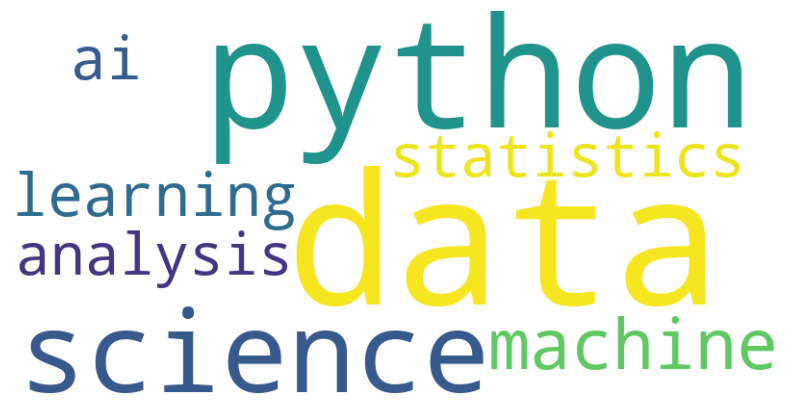

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Текст для аналізу
text = "data science python machine learning ai statistics python analysis data"

# Створення хмари слів
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Відображення хмари слів
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Тепер побудуємо WordCloud для нашого набору даних з описами вакансій.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv('data/data_science_vacs.csv')

Давайте видалимо стоп-слова. Тут у нас зустрічаються українські тексти в тому числі, і завантажити стопслова для української ми можемо звідси: https://github.com/skupriienko/Ukrainian-Stopwords

In [28]:
stopwords_ua = pd.read_csv("data/stopwords_ua.txt", header=None, names=['stopwords'])
stopwords_ua = list(stopwords_ua.stopwords)

In [29]:
stopwords_list = stopwords_ua + stopwords.words('english')

In [35]:
stopwords_list[:10], stopwords_list[-10:]

(['а',
  'аби',
  'абиде',
  'абиким',
  'абикого',
  'абиколи',
  'абикому',
  'абикуди',
  'абихто',
  'абичий'],
 ['y',
  'you',
  "you'd",
  "you'll",
  'your',
  "you're",
  'yours',
  'yourself',
  'yourselves',
  "you've"])

In [36]:
text = '\n'.join(df.desc.tolist())

In [37]:
len(text)

152961

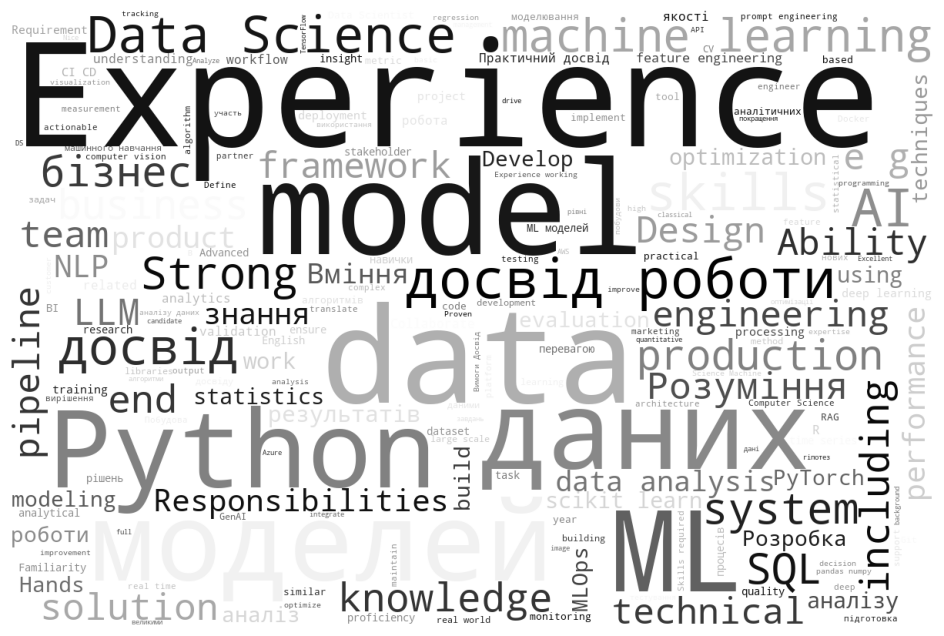

In [66]:
def create_wordcloud(text, stopwords_list, width=1200, height=800, colormap='binary', background_color='white', figsize=(14,8)):
    wc = WordCloud(
        background_color=background_color, 
        colormap = colormap, 
        stopwords = stopwords_list, 
        width = width, 
        height = height).generate(text)
    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(wc)

create_wordcloud(text, stopwords_list)

Непогано, але можна краще.
Ця хмара слів частково відображає основні поняття, які можуть бути корисними для Data Scientist, такі як "Python", "machine learning", "NLP", "data", "model", "experience", "team". Вона дає загальне уявлення про те, що є важливим у вакансіях, але не забезпечує точного фокусу на конкретних навичках, що нам було б найцікавіше знати в такому аналізі.

Проблеми з поточною хмарою слів:
1. **Невизначеність ключових слів:**  
   У хмарі з'являються слова, які не відносяться безпосередньо до навичок, наприклад, "company", "team", "work", "experience", "product". Ці слова є занадто загальними і не дають корисної інформації про технічні чи аналітичні навички, які потребує Data Scientist.

2. **Мікс термінів:**  
   Хмара слів містить як технічні терміни (наприклад, "Python", "SQL", "machine learning"), так і загальні терміни, що можуть бути частиною опису вакансії, але не є навичками ("company", "development", "team").

   
Давайте проведемо додаткову обробку аби витягнути саме навички.

## Extract skills

Скористаємось chatGPT аби з вакансії прибрати опис вакансії і сконцентруватись на вимогах до кандидата. 

Завантажуємо для початку наш API KEY.

In [40]:
# # uncomment if you don't have OPENAI_API_KEY in .env file
# import json
# import os

# creds = json.load(open('chatgpt_4_openai_creds.json'))
# os.environ['OPENAI_API_KEY'] = creds['OPENAI_API_KEY']

In [41]:
from openai import OpenAI

client = OpenAI()

In [ ]:
# creds.keys()

dict_keys(['OPENAI_API_KEY', 'OPENAI_CHAT_MODEL_NAME'])

```
{
    "OPENAI_API_KEY": "....",
    "OPENAI_CHAT_MODEL_NAME": "gpt-4o-mini"
}
```

In [42]:
openai_model_used = 'gpt-4o-mini'
max_tokens = 4096

def generate_messages(system_content, user_content):
    return [
        {
            "role": "system",
            "content": system_content            
        },
        {
            "role": "user",
            "content":  user_content
        }
    ]

def get_openai_response(messages, temperature=0, max_tokens=max_tokens, top_p=1):
    client = OpenAI()
    return client.chat.completions.create(
        model=openai_model_used,
        messages=messages,
        temperature=temperature,
        # max_tokens=max_tokens,
        top_p=top_p
    )

In [43]:
print(df.desc.loc[0])


Uklon — продуктова IT-компанія, що розробляє провідний райд-хейлінг сервіс. Щодня потужна команда Uklon прокачує одну з найбільших інфраструктур на ринку України та за її межами, забезпечуючи взаємодію драйверів та райдерів.
Ми створюємо highload продукт, за яким ховаються амбітні технологічні челенджі, безперервні інновації та неочевидні ходи. Наш фреймворк роботи — тестувати нові гіпотези, пушити свої ідеї та використовувати останній стек технологій.
Приєднуйся до нас у ролі Pricing Management Lead
Hiring process: Знайомство, тестове завдання та технічна зустріч.Деталі щодо того, як познайомитися з нашою командою дізнавайся у Віталні, Recruiter

Що ми пропонуємо саме для цієї ролі:можливість очолити стратегічний напрямок ціноутворення та безпосередньо впливати на юніт-економіку Uklon на міжнародних ринках• можливість керувати балансом попиту та пропозиції в реальному часі для мільйонів користувачів• тісна співпраця з командами Marketing, Ops, Support,Data Science, Corporate Rides, P

Задамо промпт, який дозволить нам прибрати все, що не стосується безпосередньо опису навичок кандидата.

In [51]:
prompt = """
You are provided with a technical vacancy description either in English or in Ukrainian. 
Extract only skills required for a candidate and the responsibilities. Return the extracted part 
as a plain text as it is provided without changing it.
Vacancy:
{}
"""
system_content = ''

In [52]:
generate_messages(system_content, prompt.format(df.desc.loc[0]))

[{'role': 'system', 'content': ''},
 {'role': 'user',
  'content': '\nYou are provided with a technical vacancy description either in English or in Ukrainian. \nExtract only skills required for a candidate and the responsibilities. Return the extracted part \nas a plain text as it is provided without changing it.\nVacancy:\n\nUklon\xa0— продуктова IT-компанія, що\xa0розробляє провідний райд-хейлінг сервіс. Щодня потужна команда Uklon прокачує одну з\xa0найбільших інфраструктур на\xa0ринку України та\xa0за\xa0її\xa0межами, забезпечуючи взаємодію драйверів та\xa0райдерів.\nМи\xa0створюємо highload продукт, за\xa0яким ховаються амбітні технологічні челенджі, безперервні інновації та\xa0неочевидні ходи. Наш фреймворк роботи\xa0— тестувати нові гіпотези, пушити свої ідеї та\xa0використовувати останній стек технологій.\nПриєднуйся до\xa0нас у\xa0ролі Pricing Management Lead\nHiring process: Знайомство, тестове завдання та\xa0технічна зустріч.Деталі щодо того, як\xa0познайомитися з\xa0нашою к

In [53]:
response = get_openai_response(
    generate_messages(system_content, prompt.format(df.desc.loc[0]))
)

In [54]:
response

ChatCompletion(id='chatcmpl-Dg3eyWQmxJhRl37IXWFzqdhD0EHfG', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content="**Вимоги:**\n• досвід в управлінні ціноутворенням. Розуміння стратегій максимізації доходу (досвід з механікою Dynamic Pricing буде перевагою) \n• досвід менеджменту команд аналітиків, вміння ставити цілі та розвивати тіммейтів\n• досвід планування та досягнення ключових бізнес-метрик напряму \n• сильні аналітичні здібності та досвід роботи з великими масивами даних. Вміння перетворювати цифри на бізнес-інсайти та стратегічні рішення\n• впевнене володіння інструментами аналізу та візуалізації даних (просунутий Excel, досвід із SQL, Tableau/Power BI або аналогічними інструментами буде перевагою)\n• здатність приймати самостійні рішення в умовах високої невизначеності та нести відповідальність за фінальний результат\n• сильні аналітичні здібності, вміння аналізувати великі масиви даних та знаходити інсайти\n• сильні комунікативні

In [55]:
response_text = response.model_dump()['choices'][0]['message']['content']

In [56]:
print(response_text)

**Вимоги:**
• досвід в управлінні ціноутворенням. Розуміння стратегій максимізації доходу (досвід з механікою Dynamic Pricing буде перевагою) 
• досвід менеджменту команд аналітиків, вміння ставити цілі та розвивати тіммейтів
• досвід планування та досягнення ключових бізнес-метрик напряму 
• сильні аналітичні здібності та досвід роботи з великими масивами даних. Вміння перетворювати цифри на бізнес-інсайти та стратегічні рішення
• впевнене володіння інструментами аналізу та візуалізації даних (просунутий Excel, досвід із SQL, Tableau/Power BI або аналогічними інструментами буде перевагою)
• здатність приймати самостійні рішення в умовах високої невизначеності та нести відповідальність за фінальний результат
• сильні аналітичні здібності, вміння аналізувати великі масиви даних та знаходити інсайти
• сильні комунікативні навички для ефективної співпраці з крос-функціональними командами (Product, Data Science, Marketing, Ops)
• English — B2+

**Обов'язки:**
• управління ціновою стратегіє

In [57]:
# process all vacancies

def get_skills(vacancy):
    return get_openai_response(generate_messages(system_content, prompt.format(vacancy)))

df['skills'] = df.desc.apply(get_skills)

In [58]:
df['skills_text'] = df.skills.apply(lambda x: x.model_dump()['choices'][0]['message']['content'])

In [61]:
print(df['desc'].loc[1])


Our client is a company that enables people, enterprises, and cities to harness the power of location. By making sense of the world through the lens of location, it empowers their customers to achieve better outcomes from helping a city manage its infrastructure or an enterprise optimize its assets to delivering drivers to their destination safely.What project we have for youAbout the Tour Planning Product Join us in tackling one of the most fascinating challenges in logistics: the Vehicle Routing Problem (VRP).Our client’s Tour Planning solution is the engine behind multi-vehicle route optimization, empowering businesses to design smarter, faster, and more driver-friendly tours.They harness precise and up-to-date map data, real-time traffic insights, road restrictions, and driver preferences to craft tours that are both efficient and practical. The mission is to transform complexity into clarity — delivering solutions that reduce travel time, cut costs, and keep logistics operations 

In [62]:
print(df['skills_text'].loc[1])

**Required skills:**
- Python for data analysis and automation (NumPy, Pandas, scikit-learn or equivalent).
- Statistical analysis and applied inference (hypothesis testing, confidence intervals).
- Design and implementation of evaluation frameworks: metrics definition, backtesting strategies, cross-validation, and error analysis.
- Experience validating algorithmic outputs quantitatively (rather than rule-based assertions) and designing KPI-based validation for optimization systems (e.g., distance reduction, SLA adherence, constraint violations).
- Hands-on experience with large datasets (data cleaning, aggregation, ETL).
- Experience creating visualizations and dashboards to communicate model/algorithm quality (Plotly/matplotlib/seaborn).
- Ability to program full pipelines: data ingestion → processing → evaluation → reporting/alerting.
- Collaborative mindset: work effectively with developers, QA, and product managers; translate analyses into practical recommendations.

**Responsibi

In [63]:
df.to_csv('data/data_science_vacs_enriched.csv', index=False)
df = pd.read_csv('data/data_science_vacs_enriched.csv')

In [48]:
# df[['desc', 'skills_text']]

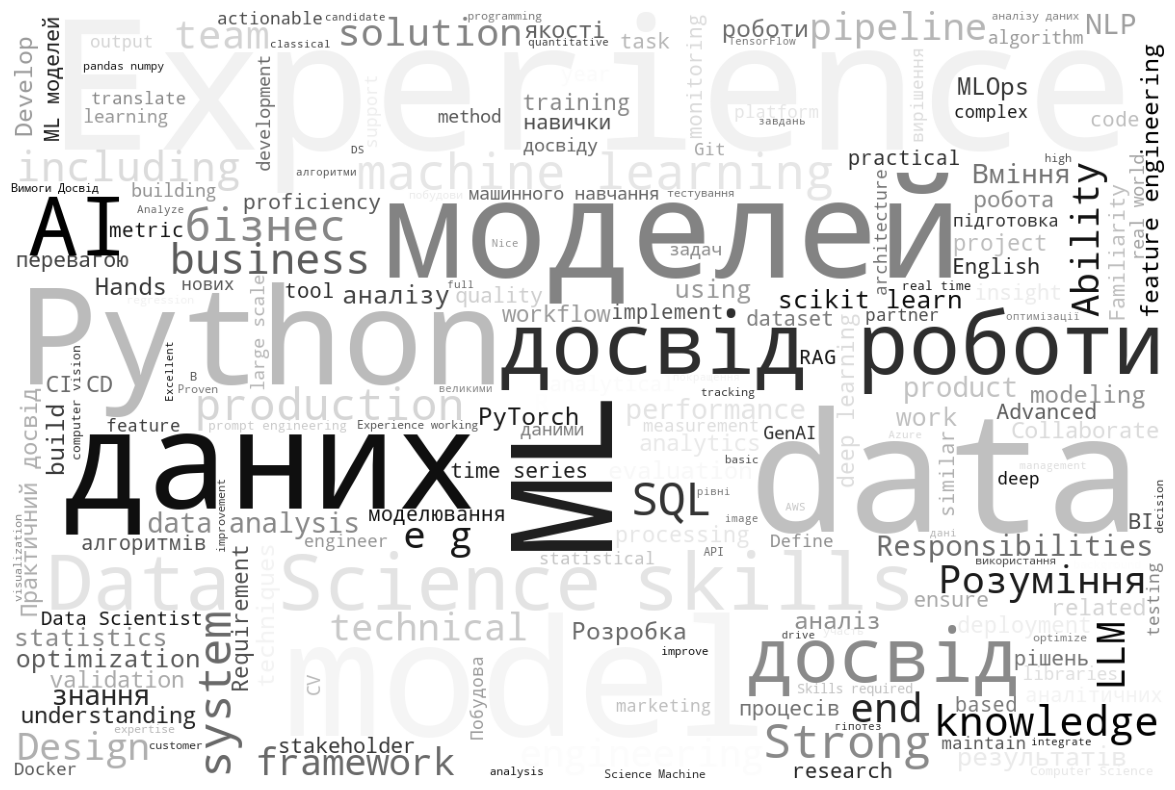

In [67]:
text = '\n'.join(df.skills_text.tolist())
create_wordcloud(text, stopwords_list, figsize=(16,10))

Все ще виглядає як трошки не то. Давайте зробимо користувацький препроцесинг. 
А для початку познайомимось з поняттям n-grams.

## Що таке N-грами

**N-grams** — це послідовності з n елементів (зазвичай слів або символів), які використовуються в обробці природної мови (NLP) для аналізу тексту. N може бути будь-яким цілим числом і вказує кількість елементів у послідовності.

### Типи n-grams:
1. **Unigram (1-gram):**  
   Це окремі слова або символи в тексті. Наприклад, у реченні "I love Python", уніграми будуть:
   - I
   - love
   - Python

2. **Bigram (2-gram):**  
   Це послідовності з двох слів або символів. Для того ж речення "I love Python", біграми будуть:
   - I love
   - love Python

3. **Trigram (3-gram):**  
   Це послідовності з трьох слів або символів. У реченні "I love Python", тріграми будуть:
   - I love Python

4. **N-grams:**  
   Якщо n більше трьох, це можуть бути, наприклад, 4-grams, 5-grams тощо.

### Для чого використовують N-grams:
1. **Аналіз тексту:**  
   N-grams використовуються для виявлення частих словосполучень або шаблонів в тексті. Це особливо корисно для розуміння структури тексту або для аналізу мови.

2. **Моделювання мови:**  
   N-grams допомагають прогнозувати наступне слово в реченні на основі попередніх слів. Це ключовий підхід у задачах, таких як автозаповнення тексту чи машинний переклад.

3. **Класифікація тексту:**  
   N-grams часто використовуються як ознаки для моделювання текстової класифікації, наприклад, у задачах аналізу настроїв або виявлення спаму.

4. **Аналіз послідовностей:**  
   N-grams можуть використовуватись для аналізу біологічних послідовностей (ДНК) або інших форм послідовних даних.

### Приклад коду в Python з використанням `nltk` для генерації біграм:


In [68]:
import nltk
from nltk import ngrams

text = "I love Python programming"
tokens = nltk.word_tokenize(text)

# Генерація біграм
bigrams = list(ngrams(tokens, 2))
print(bigrams)

[('I', 'love'), ('love', 'Python'), ('Python', 'programming')]


Використаємо n-грами в нашому аналізі. В WordCloud за замовченням беруться до уваги unigrams and bigrams - можна в цьому переконатись в [сорс коді бібліотеки](https://github.com/amueller/word_cloud/blob/main/wordcloud/wordcloud.py#L598).

In [74]:
import nltk
from nltk import word_tokenize
from nltk.util import bigrams
from collections import Counter
import re

nltk.download('punkt') 

def clean_text(text):
    # Remove non-word characters
    text = re.sub(r'\W+', ' ', text).lower()
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = [word for word in tokens if word not in stop_words]
    # Join cleaned tokens back into a string
    return ' '.join(cleaned_tokens)

# re-define text var
text = '\n'.join(df.skills_text.tolist())

tokens = word_tokenize(clean_text(text.lower()))  # Tokenize and convert to lower case
bigram_list = list(bigrams(tokens))
bigram_freq = Counter(bigram_list)



[nltk_data] Downloading package punkt to
[nltk_data]     /Users/maksymstefanko/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [75]:
bigram_freq_d = dict(bigram_freq)

In [76]:
bigram_freq_d = {' '.join(k):v for k, v in bigram_freq_d.items()}

In [77]:
bigram_df = pd.DataFrame(bigram_freq_d.items(), columns=['bigram', 'freq'])

In [78]:
bigram_df.sort_values(by = 'freq', ascending=False)[:30]

,bigram,freq
39,роботи з,44
38,досвід роботи,44
106,data science,37
695,machine learning,33
370,e g,22
327,data analysis,19
332,scikit learn,16
983,feature engineering,15
935,практичний досвід,14
1730,робота з,13


In [79]:
df['contains llm'] = df.desc.str.lower().apply(lambda x: 'llm' in x or 'generative' in x)

In [80]:
df['contains neural'] = df.desc.str.lower().apply(lambda x: 'neural' in x or 'deep' in x)

In [82]:
df['contains cv'] = df.desc.str.lower().apply(lambda x: 'computer vision' in x or 'cv' in x)

In [83]:
df.to_csv('data/data_science_vacs_enriched.csv', index=False)

In [84]:
df['contains llm'].value_counts()

contains llm
False    32
True     17
Name: count, dtype: int64

In [85]:
df['contains neural'].value_counts()

contains neural
False    28
True     21
Name: count, dtype: int64

In [86]:
df['contains cv'].value_counts()

contains cv
False    36
True     13
Name: count, dtype: int64

In [87]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.max_colwidth = None

# df[df['contains llm']][['name','desc', 'link']]

In [55]:
# df[df['contains neural']][['name','desc', 'link']]